# Background Imports & Helpers

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy import stats
from itertools import combinations
from scipy.stats import ttest_rel, ttest_ind

In [2]:
def plot_dfs_metric(dfs_with_labels, metric, dataset=''):
    plt.figure(figsize=(10, 6))
    for df_data, label in dfs_with_labels:
        plt.plot(df_data['n_iter'], df_data[f'{metric}_selector'], label=label)

    plt.xlabel('Iterations')
    plt.ylabel(f'{metric.replace("_", " ")}')
    plt.title(f'{dataset} - {metric.replace("_", " ")} over Iterations')
    plt.legend()
    plt.grid(True)
    plt.show()

In [3]:
def plot_dfs_metric_with_band(list_of_dfs_groups_with_labels, metric, dataset="", x_axis_iters=False):
    plt.figure(figsize=(10, 6))

    for dfs_group, group_label in list_of_dfs_groups_with_labels:
        # Extract x (assumes all runs share same n_iter within a group)
        if x_axis_iters:
            x = dfs_group[0]['n_iter'].values
            x_label = 'Iterations'
        else:
            x = dfs_group[0]['id_prior_al'].apply(eval).apply(len)
            x_label = 'Dataset Size'

        # Stack all runs for this group
        ys = []
        for df in dfs_group:
            ys.append(df[f'{metric}_selector'].values)
        ys = np.vstack(ys)

        # Compute stats for this group
        mean = ys.mean(axis=0)
        std = ys.std(axis=0)

        # Plot mean + band for this group
        plt.plot(x, mean, label=group_label, linewidth=2)
        plt.fill_between(x, mean - std, mean + std, alpha=0.2)

    plt.xlabel(x_label)
    plt.ylabel(f'{metric.replace("_", " ")}')
    plt.title(f'{dataset} - {metric.replace("_", " ")} over Iterations')
    plt.legend()
    plt.grid(True)
    plt.show()

# PGP

## MLP

In [22]:
# PGP: MLP (Explorative) AL
pgp_exp_mlp_nf1 = pd.read_csv("./test data/pgp/mlp/pgp_mlp_nf/al_traj.csv")
pgp_exp_mlp_nf1.dropna(inplace=True)

pgp_exp_mlp_nf2 = pd.read_csv("./test data/pgp/mlp/pgp_mlp_explorative_nf2/al_traj.csv")
pgp_exp_mlp_nf2.dropna(inplace=True)

pgp_exp_mlp_nf3 = pd.read_csv("./test data/pgp/mlp/pgp_mlp_explorative_nf3/al_traj.csv")
pgp_exp_mlp_nf3.dropna(inplace=True)

# PGP: MLP (Explorative) AL - Add 1 at a time
pgp_exp_mlp_nf1_add1 = pd.read_csv("./test data/pgp/mlp/pgp_mlp_nf_add1_1/al_traj.csv")
pgp_exp_mlp_nf1_add1.dropna(inplace=True)

pgp_exp_mlp_nf2_add1 = pd.read_csv("./test data/pgp/mlp/pgp_mlp_nf_add1_2/al_traj.csv")
pgp_exp_mlp_nf2_add1.dropna(inplace=True)

pgp_exp_mlp_nf3_add1 = pd.read_csv("./test data/pgp/mlp/pgp_mlp_nf_add1_3/al_traj.csv")
pgp_exp_mlp_nf3_add1.dropna(inplace=True)

# PGP: MLP (Explorative) AL w/ min forgetting
pgp_exp_mlp_minf1 = pd.read_csv("./test data/pgp/mlp/pgp_mlp_forget/al_traj.csv")
pgp_exp_mlp_minf1.dropna(inplace=True)

pgp_exp_mlp_minf2 = pd.read_csv("./test data/pgp/mlp/pgp_mlp_minf2/al_traj.csv")
pgp_exp_mlp_minf2.dropna(inplace=True)

pgp_exp_mlp_minf3 = pd.read_csv("./test data/pgp/mlp/pgp_mlp_minf3/al_traj.csv")
pgp_exp_mlp_minf3.dropna(inplace=True)

# PGP: MLP (Explorative) AL w/ max forgetting
pgp_exp_mlp_maxf1 = pd.read_csv("./test data/pgp/mlp/pgp_mlp_maxf/al_traj.csv")
pgp_exp_mlp_maxf1.dropna(inplace=True)

pgp_exp_mlp_maxf2 = pd.read_csv("./test data/pgp/mlp/pgp_mlp_maxf2/al_traj.csv")
pgp_exp_mlp_maxf2.dropna(inplace=True)

pgp_exp_mlp_maxf3 = pd.read_csv("./test data/pgp/mlp/pgp_mlp_maxf3/al_traj.csv")
pgp_exp_mlp_maxf3.dropna(inplace=True)

# PGP: MLP (Explorative) AL w/ random forgetting
pgp_exp_mlp_randf1 = pd.read_csv("./test data/pgp/mlp/pgp_mlp_randomforget_1/al_traj.csv")
pgp_exp_mlp_randf1.dropna(inplace=True, subset=['roc_auc_selector'])

## RF

In [5]:
# PGP: RF (Explorative) AL - Add 2 at a time
pgp_exp_rf_nf1 = pd.read_csv("./test data/pgp/rf/pgp_rf_explorative_nf/al_traj.csv")
pgp_exp_rf_nf1.dropna(inplace=True)

pgp_exp_rf_nf2 = pd.read_csv("./test data/pgp/rf/pgp_rf_explorative_nf2/al_traj.csv")
pgp_exp_rf_nf2.dropna(inplace=True)

pgp_exp_rf_nf3 = pd.read_csv("./test data/pgp/rf/pgp_rf_explorative_nf3/al_traj.csv")
pgp_exp_rf_nf3.dropna(inplace=True)

# PGP: RF (Explorative) AL - Add 1 at a time
pgp_exp_rf_nf1_add1 = pd.read_csv("./test data/pgp/rf/pgp_rf_nf_add1_1/al_traj.csv")
pgp_exp_rf_nf1_add1.dropna(inplace=True)

pgp_exp_rf_nf2_add1 = pd.read_csv("./test data/pgp/rf/pgp_rf_nf_add1_2/al_traj.csv")
pgp_exp_rf_nf2_add1.dropna(inplace=True)

pgp_exp_rf_nf3_add1 = pd.read_csv("./test data/pgp/rf/pgp_rf_nf_add1_3/al_traj.csv")
pgp_exp_rf_nf3_add1.dropna(inplace=True)

# PGP: RF (Explorative) AL w/ min forgetting
pgp_exp_rf_minf1 = pd.read_csv("./test data/pgp/rf/pgp_rf_explorative_minf/al_traj.csv")
pgp_exp_rf_minf1.dropna(inplace=True)

pgp_exp_rf_minf2 = pd.read_csv("./test data/pgp/rf/pgp_rf_explorative_minf2/al_traj.csv")
pgp_exp_rf_minf2.dropna(inplace=True)

pgp_exp_rf_minf3 = pd.read_csv("./test data/pgp/rf/pgp_rf_explorative_minf3/al_traj.csv")
pgp_exp_rf_minf3.dropna(inplace=True)

# PGP: RF (Explorative) AL w/ max forgetting
pgp_exp_rf_maxf1 = pd.read_csv("./test data/pgp/rf/pgp_rf_explorative_maxf/al_traj.csv")
pgp_exp_rf_maxf1.dropna(inplace=True)

pgp_exp_rf_maxf2 = pd.read_csv("./test data/pgp/rf/pgp_rf_explorative_maxf2/al_traj.csv")
pgp_exp_rf_maxf2.dropna(inplace=True)

pgp_exp_rf_maxf3 = pd.read_csv("./test data/pgp/rf/pgp_rf_explorative_maxf3/al_traj.csv")
pgp_exp_rf_maxf3.dropna(inplace=True)

## Chemprop

In [6]:
# PGP: Chemprop (Explorative) AL
pgp_exp_chemprop_nf1 = pd.read_csv("./test data/pgp/chemprop/pgp_chemprop_explorative_nf/al_traj.csv")
pgp_exp_chemprop_nf1.dropna(inplace=True)

pgp_exp_chemprop_nf2 = pd.read_csv("./test data/pgp/chemprop/pgp_chemprop_explorative_nf2/al_traj.csv")
pgp_exp_chemprop_nf2.dropna(inplace=True)

pgp_exp_chemprop_nf3 = pd.read_csv("./test data/pgp/chemprop/pgp_chemprop_explorative_nf3/al_traj.csv")
pgp_exp_chemprop_nf3.dropna(inplace=True)

# PGP: cp (Explorative) AL - Add 1 at a time
pgp_exp_cp_nf1_add1 = pd.read_csv("./test data/pgp/chemprop/pgp_cp_nf_add1_1/al_traj.csv")
pgp_exp_cp_nf1_add1.dropna(inplace=True)

pgp_exp_cp_nf2_add1 = pd.read_csv("./test data/pgp/chemprop/pgp_cp_nf_add1_2/al_traj.csv")
pgp_exp_cp_nf2_add1.dropna(inplace=True)

pgp_exp_cp_nf3_add1 = pd.read_csv("./test data/pgp/chemprop/pgp_cp_nf_add1_3/al_traj.csv")
pgp_exp_cp_nf3_add1.dropna(inplace=True)

## Plotting

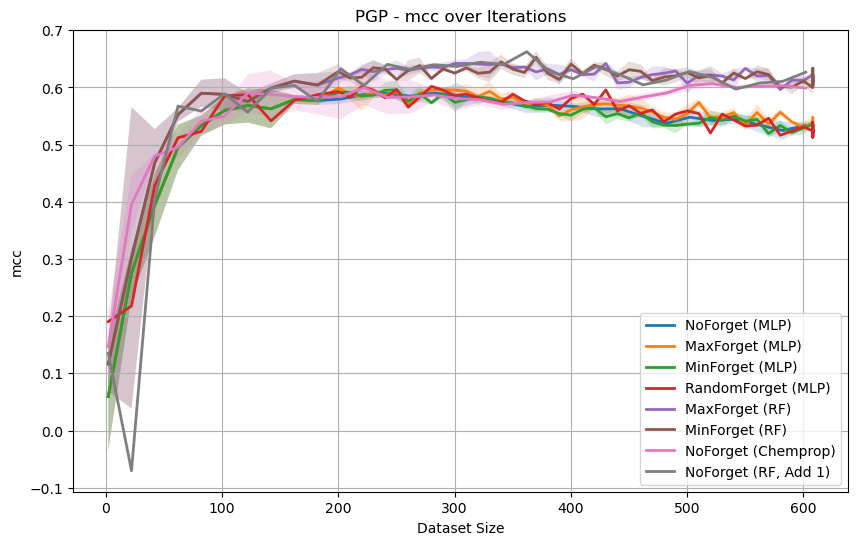

In [35]:
# MLP
dfs_pgp_nf_mlp = [
    pgp_exp_mlp_nf1,
    pgp_exp_mlp_nf2,
    pgp_exp_mlp_nf3
]

dfs_pgp_maxf_mlp = [
    pgp_exp_mlp_maxf1,
    pgp_exp_mlp_maxf2,
    pgp_exp_mlp_maxf3
]

dfs_pgp_minf_mlp = [
    pgp_exp_mlp_minf1,
    pgp_exp_mlp_minf2,
    pgp_exp_mlp_minf3
]

dfs_pgp_randf_mlp = [
    pgp_exp_mlp_randf1,
]

dfs_pgp_nf_mlp_add1 = [
    pgp_exp_mlp_nf1_add1,
    pgp_exp_mlp_nf2_add1,
    pgp_exp_mlp_nf3_add1
]

# RF
dfs_pgp_nf_rf = [
    pgp_exp_rf_nf1,
    pgp_exp_rf_nf2,
    pgp_exp_rf_nf3
]

dfs_pgp_nf_rf_add1 = [
    pgp_exp_rf_nf1_add1,
    pgp_exp_rf_nf2_add1,
    pgp_exp_rf_nf3_add1
]

dfs_pgp_minf_rf = [
    pgp_exp_rf_minf1,
    pgp_exp_rf_minf2,
    pgp_exp_rf_minf3
]

dfs_pgp_maxf_rf = [
    pgp_exp_rf_maxf1,
    pgp_exp_rf_maxf2,
    pgp_exp_rf_maxf3
]

# Chemprop
dfs_pgp_nf_chemprop = [
    pgp_exp_chemprop_nf1,
    pgp_exp_chemprop_nf2,
    pgp_exp_chemprop_nf3
]

dfs_pgp_nf_cp_add1 = [
    pgp_exp_cp_nf1_add1,
    pgp_exp_cp_nf2_add1,
    pgp_exp_cp_nf3_add1
]

In [ ]:
plot_dfs_metric_with_band(
    [
        # (dfs_pgp_nf_mlp, "NoForget (MLP)"),
        (dfs_pgp_maxf_mlp, "MaxForget (MLP)"),
        (dfs_pgp_minf_mlp, "MinForget (MLP)"),
        (dfs_pgp_randf_mlp, "RandomForget (MLP)"),
        (dfs_pgp_maxf_rf, "MaxForget (RF)"),
        (dfs_pgp_minf_rf, "MinForget (RF)"),
        # (dfs_pgp_nf_chemprop, "NoForget (Chemprop)"),
        # (dfs_pgp_nf_rf, "NoForget (RF)"),
        (dfs_pgp_nf_mlp_add1, "NoForget (MLP, Add 1)"),
        (dfs_pgp_nf_rf_add1, "NoForget (RF, Add 1)"),
        (dfs_pgp_nf_cp_add1, "NoForget (Chemprop, Add 1)"),
        # (dfs_mlp_forget2, "forget 2")
    ],
    metric="mcc",
    dataset="PGP",
    x_axis_iters=True
)

### Plotting different modifications:

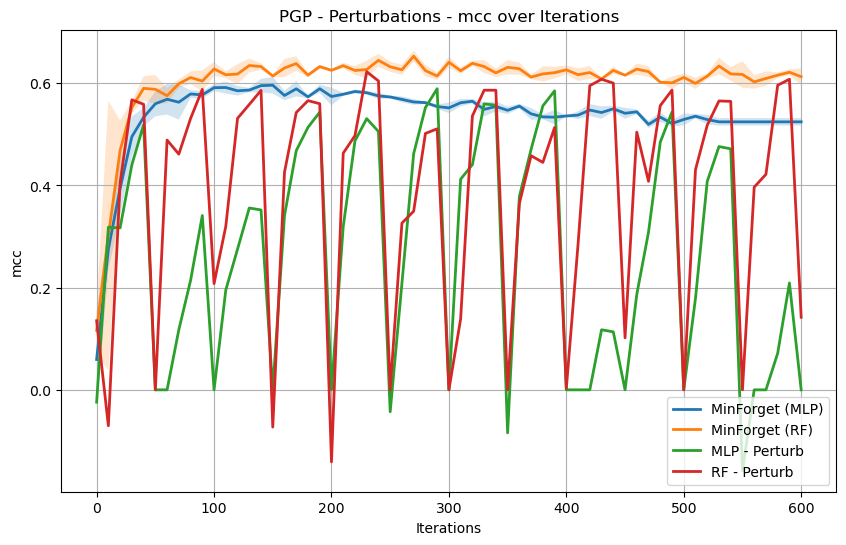

In [32]:
# Perturbing Values w/ Forgetting
df_rf_perturb100_1 = pd.read_csv("./test data/pgp/rf/pgp_rf_minf_perturb100/al_traj.csv")
df_rf_perturb100_1.dropna(inplace=True)

df_mlp_perturb100_1 = pd.read_csv("./test data/pgp/mlp/pgp_mlp_minf_perturb100/al_traj.csv")
df_mlp_perturb100_1.dropna(inplace=True)

dfs_rf_perturb100 = [
    df_rf_perturb100_1
]

dfs_mlp_perturb100 = [
    df_mlp_perturb100_1
]

plot_dfs_metric_with_band(
    [
        (dfs_pgp_minf_mlp, "MinForget (MLP)"),
        (dfs_pgp_minf_rf, "MinForget (RF)"),
        (dfs_mlp_perturb100, "MLP - Perturb"),
        (dfs_rf_perturb100, "RF - Perturb")
    ],
    metric="mcc",
    dataset="PGP - Perturbations",
    x_axis_iters=True
)

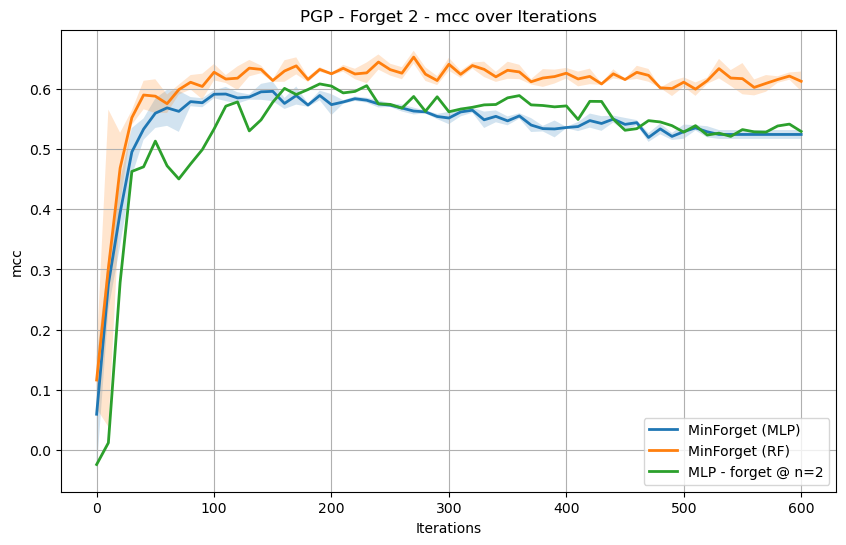

In [34]:
# Start forgetting @ n = 2 datapoints in train set
df_mlp_forget2_1 = pd.read_csv("./test data/pgp/mlp/pgp_mlp_minf_forgetsize2/al_traj.csv")
df_mlp_forget2_1.dropna(inplace=True)

df_mlp_forget2_2 = pd.read_csv("./test data/pgp/mlp/pgp_mlp_minf_forgetsize2_2/al_traj.csv")
df_mlp_forget2_2.dropna(inplace=True)

df_mlp_forget2_3 = pd.read_csv("./test data/pgp/mlp/pgp_mlp_minf_forgetsize2_3/al_traj.csv")
df_mlp_forget2_3.dropna(inplace=True)

dfs_mlp_forget2 = [
    df_mlp_forget2_1,
    df_mlp_forget2_2,
    df_mlp_forget2_3
]

plot_dfs_metric_with_band(
    [
        (dfs_pgp_minf_mlp, "MinForget (MLP)"),
        (dfs_pgp_minf_rf, "MinForget (RF)"),
        (dfs_mlp_forget2, "MLP - forget @ n=2")
    ],
    metric="mcc",
    dataset="PGP - Forget 2",
    x_axis_iters=True
)

## Attempting Statistics

In [29]:
def compute_auc_for_run(df, metric, x_axis_iters=False, normalize=True):
    if x_axis_iters:
        x = df["n_iter"].values
    else:
        x = df["id_prior_al"].apply(eval).apply(len).values

    y = df[f"{metric}_selector"].values

    auc = np.trapz(y, x)

    # Normalize by x-range so AUC is comparable as an average-over-curve
    if normalize:
        x_range = x.max() - x.min()
        if x_range > 0:
            auc = auc / x_range

    return auc


def extract_group_aucs(list_of_dfs_groups_with_labels, metric, x_axis_iters=False, normalize=True):
    aucs_by_group = {}

    for dfs_group, group_label in list_of_dfs_groups_with_labels:
        aucs = [
            compute_auc_for_run(df, metric, x_axis_iters=x_axis_iters, normalize=normalize)
            for df in dfs_group
        ]
        aucs_by_group[group_label] = np.array(aucs)

    return aucs_by_group

def pairwise_auc_tests(
    list_of_dfs_groups_with_labels,
    metric,
    x_axis_iters=False,
    normalize=True,
    paired=True
):
    aucs_by_group = extract_group_aucs(
        list_of_dfs_groups_with_labels,
        metric=metric,
        x_axis_iters=x_axis_iters,
        normalize=normalize
    )

    rows = []
    labels = list(aucs_by_group.keys())

    for g1, g2 in combinations(labels, 2):
        a = aucs_by_group[g1]
        b = aucs_by_group[g2]

        if paired:
            if len(a) != len(b):
                raise ValueError(f"Paired test requires equal runs: {g1} has {len(a)}, {g2} has {len(b)}")
            stat, p = ttest_rel(a, b)
            test_name = "paired t-test"
        else:
            stat, p = ttest_ind(a, b, equal_var=False)
            test_name = "Welch's t-test"

        rows.append({
            "group_1": g1,
            "group_2": g2,
            "mean_auc_1": a.mean(),
            "mean_auc_2": b.mean(),
            "diff_1_minus_2": a.mean() - b.mean(),
            "statistic": stat,
            "p_value": p,
            "test": test_name,
        })

    return pd.DataFrame(rows).sort_values("p_value")

In [27]:
groups = [
    (dfs_pgp_nf_mlp, "NoForget (MLP)"),
    (dfs_pgp_maxf_mlp, "MaxForget (MLP)"),
    (dfs_pgp_minf_mlp, "MinForget (MLP)"),
    (dfs_pgp_randf_mlp, "RandomForget (MLP)"),
    (dfs_pgp_maxf_rf, "MaxForget (RF)"),
    (dfs_pgp_minf_rf, "MinForget (RF)"),
    (dfs_pgp_nf_chemprop, "NoForget (Chemprop)"),
    (dfs_pgp_nf_rf_add1, "NoForget (RF, Add 1)"),
]

aucs_by_group = extract_group_aucs(
    groups,
    metric="mcc",
    x_axis_iters=True,
    normalize=True
)

for label, aucs in aucs_by_group.items():
    print(label, "mean AUC =", aucs.mean(), "std =", aucs.std(ddof=1), "n =", len(aucs))

NoForget (MLP) mean AUC = 0.5373840924908172 std = 0.003014469360723458 n = 3
MaxForget (MLP) mean AUC = 0.5517466800741172 std = 0.004360589646197619 n = 3
MinForget (MLP) mean AUC = 0.5424898448456704 std = 0.002403185037706896 n = 3
RandomForget (MLP) mean AUC = 0.5483917842164843 std = nan n = 1
MaxForget (RF) mean AUC = 0.6077521666846789 std = 0.010135662646906652 n = 3
MinForget (RF) mean AUC = 0.6065598243642291 std = 0.006421791845322642 n = 3
NoForget (Chemprop) mean AUC = 0.564247243180532 std = 0.007046829811346835 n = 3
NoForget (RF, Add 1) mean AUC = 0.5758982283771855 std = 0.0 n = 3


/opt/apps/rhel9/Anaconda3-2024.02/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/apps/rhel9/Anaconda3-2024.02/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [31]:
results = pairwise_auc_tests(
    groups,
    metric="mcc",
    x_axis_iters=True,
    normalize=True,
    paired=False   # change to False if runs are not matched
)

print(results)

                group_1               group_2  mean_auc_1  mean_auc_2  \
10      MaxForget (MLP)        MinForget (RF)    0.551747    0.606560   
4        NoForget (MLP)        MinForget (RF)    0.537384    0.606560   
15      MinForget (MLP)        MinForget (RF)    0.542490    0.606560   
25       MinForget (RF)   NoForget (Chemprop)    0.606560    0.564247   
17      MinForget (MLP)  NoForget (RF, Add 1)    0.542490    0.575898   
6        NoForget (MLP)  NoForget (RF, Add 1)    0.537384    0.575898   
3        NoForget (MLP)        MaxForget (RF)    0.537384    0.607752   
9       MaxForget (MLP)        MaxForget (RF)    0.551747    0.607752   
23       MaxForget (RF)   NoForget (Chemprop)    0.607752    0.564247   
14      MinForget (MLP)        MaxForget (RF)    0.542490    0.607752   
12      MaxForget (MLP)  NoForget (RF, Add 1)    0.551747    0.575898   
5        NoForget (MLP)   NoForget (Chemprop)    0.537384    0.564247   
0        NoForget (MLP)       MaxForget (MLP)    0.

/opt/apps/rhel9/Anaconda3-2024.02/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1103: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/opt/apps/rhel9/Anaconda3-2024.02/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1103: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/opt/apps/rhel9/Anaconda3-2024.02/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:523: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


# CYP

## MLP

In [10]:
# CYP: MLP (Explorative) AL
cyp_exp_mlp_nf1 = pd.read_csv("./test data/cyp/mlp/cyp_mlp_explorative_nf/al_traj.csv")
cyp_exp_mlp_nf1.dropna(inplace=True)

cyp_exp_mlp_nf2 = pd.read_csv("./test data/cyp/mlp/cyp_mlp_explorative_nf2/al_traj.csv")
cyp_exp_mlp_nf2.dropna(inplace=True)    

cyp_exp_mlp_nf3 = pd.read_csv("./test data/cyp/mlp/cyp_mlp_explorative_nf3/al_traj.csv")
cyp_exp_mlp_nf3.dropna(inplace=True)

# CYP: MLP (Explorative) AL w/ min forgetting
cyp_exp_mlp_minf1 = pd.read_csv("./test data/cyp/mlp/cyp_mlp_explorative_minf/al_traj.csv")
cyp_exp_mlp_minf1.dropna(inplace=True)

# cyp_exp_mlp_minf2 = pd.read_csv("./test data/cyp/mlp/cyp_mlp_explorative_minf2/al_traj.csv")
# cyp_exp_mlp_minf2.dropna(inplace=True)

# cyp_exp_mlp_minf3 = pd.read_csv("./test data/cyp/mlp/cyp_mlp_minf3/al_traj.csv")
# cyp_exp_mlp_minf3.dropna(inplace=True)

# CYP: MLP (Explorative) AL w/ max forgetting
cyp_exp_mlp_maxf1 = pd.read_csv("./test data/cyp/mlp/cyp_mlp_maxf/al_traj.csv")
cyp_exp_mlp_maxf1.dropna(inplace=True)

cyp_exp_mlp_maxf2 = pd.read_csv("./test data/cyp/mlp/cyp_mlp_maxf2/al_traj.csv")
cyp_exp_mlp_maxf2.dropna(inplace=True)

cyp_exp_mlp_maxf3 = pd.read_csv("./test data/cyp/mlp/cyp_mlp_maxf3/al_traj.csv")
cyp_exp_mlp_maxf3.dropna(inplace=True)

## RF

In [11]:
# CYP: RF (Explorative) AL
cyp_exp_rf_nf1 = pd.read_csv("./test data/cyp/rf/cyp_rf_explorative_nf/al_traj.csv")
cyp_exp_rf_nf1.dropna(inplace=True)

# cyp_exp_rf_nf2 = pd.read_csv("./test data/cyp/rf/cyp_rf_explorative_nf2/al_traj.csv")
# cyp_exp_rf_nf2.dropna(inplace=True)

# cyp_exp_rf_nf3 = pd.read_csv("./test data/cyp/rf/cyp_rf_explorative_nf3/al_traj.csv")
# cyp_exp_rf_nf3.dropna(inplace=True)

# CYP: RF (Explorative) AL w/ min forgetting
cyp_exp_rf_minf1 = pd.read_csv("./test data/cyp/rf/cyp_rf_explorative_minf/al_traj.csv")
cyp_exp_rf_minf1.dropna(inplace=True)

# cyp_exp_rf_minf2 = pd.read_csv("./test data/cyp/rf/cyp_rf_minf2/al_traj.csv")
# cyp_exp_rf_minf2.dropna(inplace=True)

# cyp_exp_rf_minf3 = pd.read_csv("./test data/cyp/rf/cyp_rf_minf3/al_traj.csv")
# cyp_exp_rf_minf3.dropna(inplace=True)

# # CYP: RF (Explorative) AL w/ max forgetting
# cyp_exp_rf_maxf1 = pd.read_csv("./test data/cyp/rf/cyp_rf_maxf/al_traj.csv")
# cyp_exp_rf_maxf1.dropna(inplace=True)

# cyp_exp_rf_maxf2 = pd.read_csv("./test data/cyp/rf/cyp_rf_maxf2/al_traj.csv")
# cyp_exp_rf_maxf2.dropna(inplace=True)

# cyp_exp_rf_maxf3 = pd.read_csv("./test data/cyp/rf/cyp_rf_maxf3/al_traj.csv")
# cyp_exp_rf_maxf3.dropna(inplace=True)


## Chemprop

In [12]:
# # CYP: Chemprop (Explorative) AL
# cyp_exp_chemprop_nf1 = pd.read_csv("./test data/cyp/chemprop/cyp_chemprop_nf/al_traj.csv")
# cyp_exp_chemprop_nf1.dropna(inplace=True)

# cyp_exp_chemprop_nf2 = pd.read_csv("./test data/cyp/chemprop/cyp_chemprop_nf2/al_traj.csv")
# cyp_exp_chemprop_nf2.dropna(inplace=True)

# cyp_exp_chemprop_nf3 = pd.read_csv("./test data/cyp/chemprop/cyp_chemprop_nf3/al_traj.csv")
# cyp_exp_chemprop_nf3.dropna(inplace=True)

## Plotting

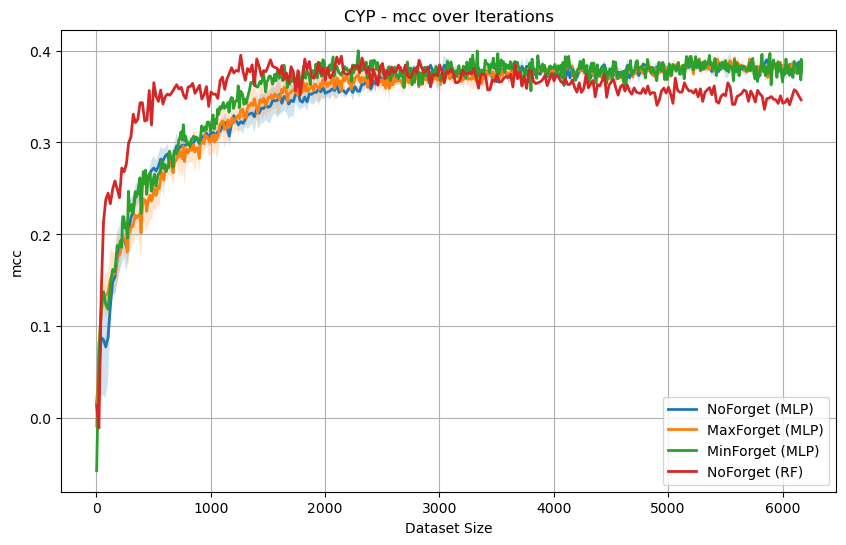

In [13]:
dfs_cyp_nf_mlp = [
    cyp_exp_mlp_nf1,
    cyp_exp_mlp_nf2,
    cyp_exp_mlp_nf3
]

dfs_cyp_maxf_mlp = [
    cyp_exp_mlp_maxf1,
    cyp_exp_mlp_maxf2,
    cyp_exp_mlp_maxf3
]

dfs_cyp_minf_mlp = [
    cyp_exp_mlp_minf1,
    # cyp_exp_mlp_minf2,
    # cyp_exp_mlp_minf3
]

dfs_cyp_nf_rf = [
    cyp_exp_rf_nf1,
    # cyp_exp_rf_nf2,
    # cyp_exp_rf_nf3
]

dfs_cyp_nf_chemprop = [
    # cyp_exp_chemprop_nf1,
    # cyp_exp_chemprop_nf2,
    # cyp_exp_chemprop_nf3
]

plot_dfs_metric_with_band(
    [
        (dfs_cyp_nf_mlp, "NoForget (MLP)"),
        (dfs_cyp_maxf_mlp, "MaxForget (MLP)"),
        (dfs_cyp_minf_mlp, "MinForget (MLP)"),
        # (dfs_cyp_maxf_rf, "MaxForget (RF)"),
        # (dfs_cyp_minf_rf, "MinForget (RF)"),
        # (dfs_cyp_nf_chemprop, "NoForget (Chemprop)"),
        (dfs_cyp_nf_rf, "NoForget (RF)")
    ],
    metric="mcc",
    dataset="CYP"
)